In [3]:
text = '''Machine learning is the study of computer algorithms that \
improve automatically through experience. It is seen as a \
subset of artificial intelligence. Machine learning algorithms \
build a mathematical model based on sample data, known as \
training data, in order to make predictions or decisions without \
being explicitly programmed to do so. Machine learning algorithms \
are used in a wide variety of applications, such as email filtering \
and computer vision, where it is difficult or infeasible to develop \
conventional algorithms to perform the needed tasks.'''

In [5]:
import re 

def tokenize(text):
    pattern=re.compile(r'[A-Za-z]+[\w^\']*|[\w^\']*[A-Za-z]+[\w^\']*')
    return pattern.findall(text.lower())


In [6]:
tokens=tokenize(text)

In [7]:
def mapping(tokens):
    word_to_id={}
    id_to_word = {}
    
    for i, token in enumerate(set(tokens)):
        word_to_id[token] = i
        id_to_word[i] = token
    
    return word_to_id, id_to_word
    

In [8]:
word_to_id, id_to_word = mapping(tokens)
word_to_id

{'wide': 0,
 'through': 1,
 'of': 2,
 'experience': 3,
 'develop': 4,
 'variety': 5,
 'vision': 6,
 'the': 7,
 'are': 8,
 'study': 9,
 'order': 10,
 'artificial': 11,
 'subset': 12,
 'explicitly': 13,
 'perform': 14,
 'do': 15,
 'or': 16,
 'email': 17,
 'being': 18,
 'computer': 19,
 'sample': 20,
 'predictions': 21,
 'and': 22,
 'to': 23,
 'make': 24,
 'that': 25,
 'on': 26,
 'improve': 27,
 'conventional': 28,
 'in': 29,
 'algorithms': 30,
 'training': 31,
 'it': 32,
 'automatically': 33,
 'difficult': 34,
 'infeasible': 35,
 'so': 36,
 'data': 37,
 'mathematical': 38,
 'programmed': 39,
 'model': 40,
 'seen': 41,
 'without': 42,
 'filtering': 43,
 'intelligence': 44,
 'used': 45,
 'needed': 46,
 'build': 47,
 'based': 48,
 'learning': 49,
 'known': 50,
 'such': 51,
 'decisions': 52,
 'is': 53,
 'tasks': 54,
 'applications': 55,
 'a': 56,
 'machine': 57,
 'as': 58,
 'where': 59}

In [13]:
import numpy as np

np.random.seed(42)

def generate_training_data(tokens,word_to_id,window):
    X=[]
    y=[]
    n_tokens=len(tokens)
    
    for i in range(n_tokens):
        idx=concat(
            range(max(0,i-window),i),
            range(i,min(n_tokens,i+window+1))
        )
        for j in idx:
            if i == j:
                continue
            X.append(one_hot_encode(word_to_id[tokens[i]], len(word_to_id)))
            y.append(one_hot_encode(word_to_id[tokens[j]], len(word_to_id)))
        
    return np.asarray(X), np.asarray(y)

In [11]:
def concat(*iterables):
    for iterable in iterables:
        yield from iterable

In [12]:
def one_hot_encode(id, vocab_size):
    res = [0] * vocab_size
    res[id] = 1
    return res

In [14]:
X, y = generate_training_data(tokens, word_to_id, 2)

In [15]:
X.shape

(330, 60)

In [16]:
y.shape

(330, 60)

In [17]:
def init_network(vocab_size, n_embedding):
    model = {
        "w1": np.random.randn(vocab_size, n_embedding),
        "w2": np.random.randn(n_embedding, vocab_size)
    }
    return model

In [18]:
model = init_network(len(word_to_id), 10)

In [19]:
def forward(model, X, return_cache=True):
    cache = {}
    
    cache["a1"] = X @ model["w1"]
    cache["a2"] = cache["a1"] @ model["w2"]
    cache["z"] = softmax(cache["a2"])
    
    if not return_cache:
        return cache["z"]
    return cache

In [20]:
def softmax(X):
    res = []
    for x in X:
        exp = np.exp(x)
        res.append(exp / exp.sum())
    return res

In [21]:
(X @ model["w1"]).shape

(330, 10)

In [22]:
(X @ model["w1"] @ model["w2"]).shape

(330, 60)

In [23]:
def backward(model, X, y, alpha):
    cache  = forward(model, X)
    da2 = cache["z"] - y
    dw2 = cache["a1"].T @ da2
    da1 = da2 @ model["w2"].T
    dw1 = X.T @ da1
    assert(dw2.shape == model["w2"].shape)
    assert(dw1.shape == model["w1"].shape)
    model["w1"] -= alpha * dw1
    model["w2"] -= alpha * dw2
    return cross_entropy(cache["z"], y)

In [24]:
def cross_entropy(z, y):
    return - np.sum(np.log(z) * y)

In [26]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


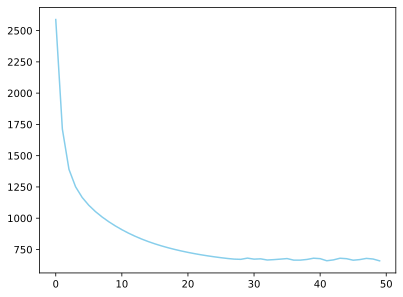

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

n_iter = 50
learning_rate = 0.05

history = [backward(model, X, y, learning_rate) for _ in range(n_iter)]

plt.plot(range(len(history)), history, color="skyblue")
plt.show()

In [29]:
learning = one_hot_encode(word_to_id["learning"], len(word_to_id))
result = forward(model, [learning], return_cache=False)[0]

for word in (id_to_word[id] for id in np.argsort(result)[::-1]):
    print(word)

algorithms
so
the
is
intelligence
machine
build
are
subset
programmed
computer
mathematical
infeasible
learning
improve
based
to
needed
difficult
artificial
used
model
where
through
in
conventional
automatically
applications
decisions
wide
sample
study
of
it
seen
make
on
predictions
a
data
explicitly
that
vision
filtering
tasks
do
variety
order
without
such
known
email
or
develop
and
perform
being
experience
training
as


In [30]:
def get_embedding(model, word):
    try:
        idx = word_to_id[word]
    except KeyError:
        print("`word` not in corpus")
    one_hot = one_hot_encode(idx, len(word_to_id))
    return forward(model, one_hot)["a1"]

In [31]:
get_embedding(model, "machine")

array([-0.69091769,  0.5859265 ,  0.96018135, -0.34436864,  1.89494358,
       -0.04816356, -0.5311867 , -0.96778814, -0.92559328, -0.28056894])